In [3]:
!pip install medmnist

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 12.4 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 21.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.3/127.3 MB 22.6 MB/s  0:00:05m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 21.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13/13 [medmnist]/13 [torchvision]]

[notice] A new release of pip is available: 26.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
from medmnist import BreastMNIST

os.makedirs("../data", exist_ok=True)       
train = BreastMNIST(split="train", download=True, root="../data")
test  = BreastMNIST(split="test",  download=True, root="../data")
print(train)

100%|██████████| 560k/560k [00:04<00:00, 138kB/s] 

Dataset BreastMNIST of size 28 (breastmnist)
    Number of datapoints: 546
    Root location: ../data
    Split: train
    Task: binary-class
    Number of channels: 1
    Meaning of labels: {'0': 'malignant', '1': 'normal, benign'}
    Number of samples: {'train': 546, 'val': 78, 'test': 156}
    Description: The BreastMNIST is based on a dataset of 780 breast ultrasound images. It is categorized into 3 classes: normal, benign, and malignant. As we use low-resolution images, we simplify the task into binary classification by combining normal and benign as positive and classifying them against malignant as negative. We split the source dataset with a ratio of 7:1:2 into training, validation and test set. The source images of 1×500×500 are resized into 1×28×28.
    License: CC BY 4.0


In [5]:
X_train_img = train.imgs            
y_train = train.labels.ravel()       

print("Shape of images:", X_train_img.shape)
print("Pixel values from", X_train_img.min(), "to", X_train_img.max())

names = {0: "malignant", 1: "normal / benign"}
for c in [0, 1]:
    print(names[c], ":", (y_train == c).sum(), "images")

Shape of images: (546, 28, 28)
Pixel values from 0 to 255
malignant : 147 images
normal / benign : 399 images


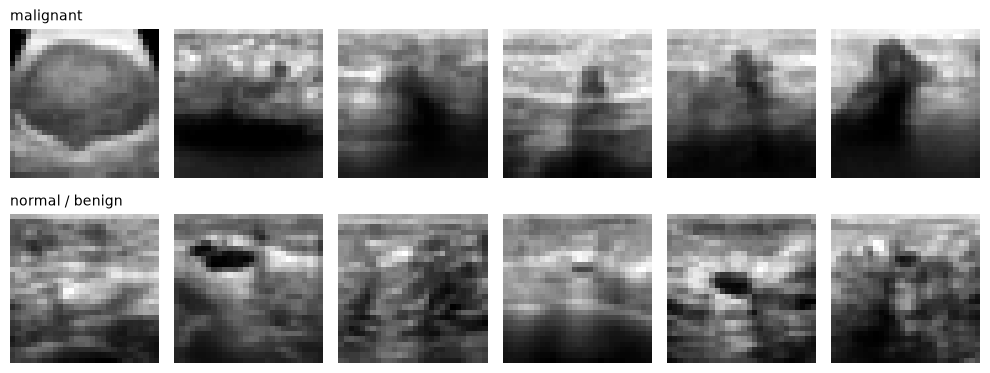

In [6]:
fig, axes = plt.subplots(2, 6, figsize=(10, 4))
for row, c in enumerate([0, 1]):
    idx = np.where(y_train == c)[0][:6]         
    for col, i in enumerate(idx):
        axes[row, col].imshow(X_train_img[i], cmap="gray")
        axes[row, col].axis("off")
    axes[row, 0].set_title(names[c], loc="left", fontsize=10)
fig.tight_layout()
os.makedirs("../results", exist_ok=True)
fig.savefig("../results/breastmnist_examples.png", dpi=150)
plt.show()

In [7]:
X_train_flat = X_train_img.reshape(len(X_train_img), -1)
print("Each image becomes", X_train_flat.shape[1], "numbers")

Each image becomes 784 numbers


100%|██████████| 30.9M/30.9M [02:12<00:00, 233kB/s] 


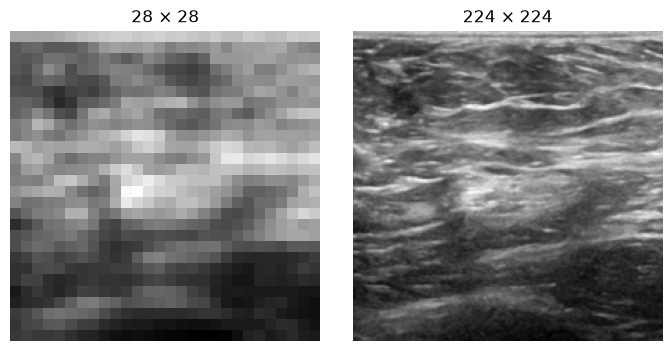

In [8]:
train224 = BreastMNIST(split="train", download=True, root="../data", size=224)

i = 0   # the first image
fig, axes = plt.subplots(1, 2, figsize=(7, 3.5))
axes[0].imshow(X_train_img[i], cmap="gray");  axes[0].set_title("28 × 28")
axes[1].imshow(train224.imgs[i], cmap="gray"); axes[1].set_title("224 × 224")
for ax in axes: ax.axis("off")
fig.tight_layout()
fig.savefig("../results/breastmnist_28_vs_224.png", dpi=150)
plt.show()